# Fullerene Experiment — Results Analysis

Compares CT, GNN (GCN/GAT/GIN), SchNet, and FullereneNet across three test sets:
- **C60**: C60 fullerenes
- **C70_non_IPR**: non-IPR C70 fullerenes
- **C72_100_IPR**: IPR fullerenes C72–C100

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
from IPython.display import display

plt.rcParams['figure.dpi'] = 130
pd.set_option('display.float_format', '{:.4f}'.format)

RESULTS_DIR = Path('results')

In [2]:
FILES = {
    'CT-full-topo':     'results_ct_full_topo.json',
    'CT-full-notopo':   'results_ct_full_notopo.json',
    'CT-simple-topo':   'results_ct_simple_topo.json',
    'CT-simple-notopo': 'results_ct_simple_notopo.json',
    'CT-none-topo':     'results_ct_none_topo.json',
    'GCN-full':         'results_GCN_full.json',
    'GCN-simple':       'results_GCN_simple.json',
    'GAT-full':         'results_GAT_full.json',
    'GAT-simple':       'results_GAT_simple.json',
    'GIN-full':         'results_GIN_full.json',
    'GIN-simple':       'results_GIN_simple.json',
    'SchNet':           'results_schnet.json',
    'FullereneNet':     'results_fullerenet.json',
}

data = {}
for label, fname in FILES.items():
    p = RESULTS_DIR / fname
    if p.exists():
        with open(p) as f:
            data[label] = json.load(f)
    else:
        print(f'Missing: {fname}')

print(f'Loaded {len(data)} result files: {list(data.keys())}')

Loaded 13 result files: ['CT-full-topo', 'CT-full-notopo', 'CT-simple-topo', 'CT-simple-notopo', 'CT-none-topo', 'GCN-full', 'GCN-simple', 'GAT-full', 'GAT-simple', 'GIN-full', 'GIN-simple', 'SchNet', 'FullereneNet']


## Summary Table

In [3]:
TEST_SETS = ['c60', 'c70_non_IPR', 'c72_100_IPR']
METRICS   = ['rmse', 'mae', 'r2']

rows = []
for label, d in data.items():
    row = {'model': label, 'num_params': d.get('num_params')}
    for ts in TEST_SETS:
        for m in METRICS:
            row[f'{m}_{ts}'] = d.get(f'mean_test_{m}_{ts}')
        run_rmses = [r[f'test_rmse_{ts}'] for r in d['runs']]
        row[f'rmse_{ts}_std'] = round(float(np.std(run_rmses)), 4)
    rows.append(row)

df = pd.DataFrame(rows).set_index('model')
print(df.shape)
df[['num_params'] + [f'rmse_{ts}' for ts in TEST_SETS]]

(13, 13)


,num_params,rmse_c60,rmse_c70_non_IPR,rmse_c72_100_IPR
model,,,,
CT-full-topo,811201,0.0130,0.0300,0.1408
CT-full-notopo,810369,0.0119,0.0227,0.1003
CT-simple-topo,808961,0.0055,0.0256,0.1175
CT-simple-notopo,808129,0.0404,0.0766,0.1977
CT-none-topo,808705,0.0044,0.0251,0.1173
GCN-full,17473,0.0505,0.0672,0.3806
GCN-simple,16961,0.0584,0.1083,0.2688
GAT-full,297665,0.0133,0.0147,0.0428
GAT-simple,288193,0.0585,0.1084,0.2689


## Per-Test-Set Rankings

Sorted by RMSE (lower is better). R² closer to 1 is better.

In [4]:
for ts in TEST_SETS:
    cols = [f'rmse_{ts}', f'rmse_{ts}_std', f'mae_{ts}', f'r2_{ts}']
    sub = df[cols].sort_values(f'rmse_{ts}')
    sub.columns = ['RMSE (mean)', 'RMSE (std)', 'MAE', 'R²']
    print(f'\n{"─"*55}  {ts}  {"─"*55}')
    display(sub.style
            .format(precision=4)
            .background_gradient(subset=['RMSE (mean)', 'MAE'], cmap='RdYlGn_r', axis=0)
            .background_gradient(subset=['R²'], cmap='RdYlGn', axis=0))


───────────────────────────────────────────────────────  c60  ───────────────────────────────────────────────────────


,RMSE (mean),RMSE (std),MAE,R²
model,,,,
FullereneNet,0.0040,0.0003,0.0030,0.9854
CT-none-topo,0.0044,0.0010,0.0035,0.9818
CT-simple-topo,0.0055,0.0022,0.0046,0.9684
SchNet,0.0060,0.0001,0.0046,0.9682
CT-full-notopo,0.0119,0.0026,0.0105,0.8665
CT-full-topo,0.0130,0.0010,0.0121,0.8469
GAT-full,0.0133,0.0011,0.0102,0.8405
GIN-simple,0.0338,0.0002,0.0262,-0.0275
CT-simple-notopo,0.0404,0.0256,0.0354,-1.0502



───────────────────────────────────────────────────────  c70_non_IPR  ───────────────────────────────────────────────────────


,RMSE (mean),RMSE (std),MAE,R²
model,,,,
FullereneNet,0.0077,0.0010,0.0065,0.9322
GAT-full,0.0147,0.0040,0.0125,0.7394
CT-full-notopo,0.0227,0.0044,0.0219,0.3961
CT-none-topo,0.0251,0.0027,0.0241,0.2806
CT-simple-topo,0.0256,0.0038,0.0247,0.2455
CT-full-topo,0.0300,0.0004,0.0292,-0.0175
GIN-simple,0.0328,0.0021,0.0259,-0.2221
SchNet,0.0381,0.0011,0.0371,-0.6474
GIN-full,0.0491,0.0069,0.0449,-1.7849



───────────────────────────────────────────────────────  c72_100_IPR  ───────────────────────────────────────────────────────


,RMSE (mean),RMSE (std),MAE,R²
model,,,,
FullereneNet,0.0324,0.0054,0.0307,-9.2911
GAT-full,0.0428,0.0261,0.0408,-23.0163
GIN-simple,0.0469,0.0109,0.0448,-21.1512
CT-full-notopo,0.1003,0.0061,0.0999,-95.6158
CT-none-topo,0.1173,0.0103,0.1168,-131.6781
CT-simple-topo,0.1175,0.0093,0.1168,-131.7851
CT-full-topo,0.1408,0.0181,0.1401,-191.8712
SchNet,0.1655,0.0018,0.1649,-261.1540
CT-simple-notopo,0.1977,0.1007,0.1972,-469.6490


## RMSE Comparison — Bar Charts

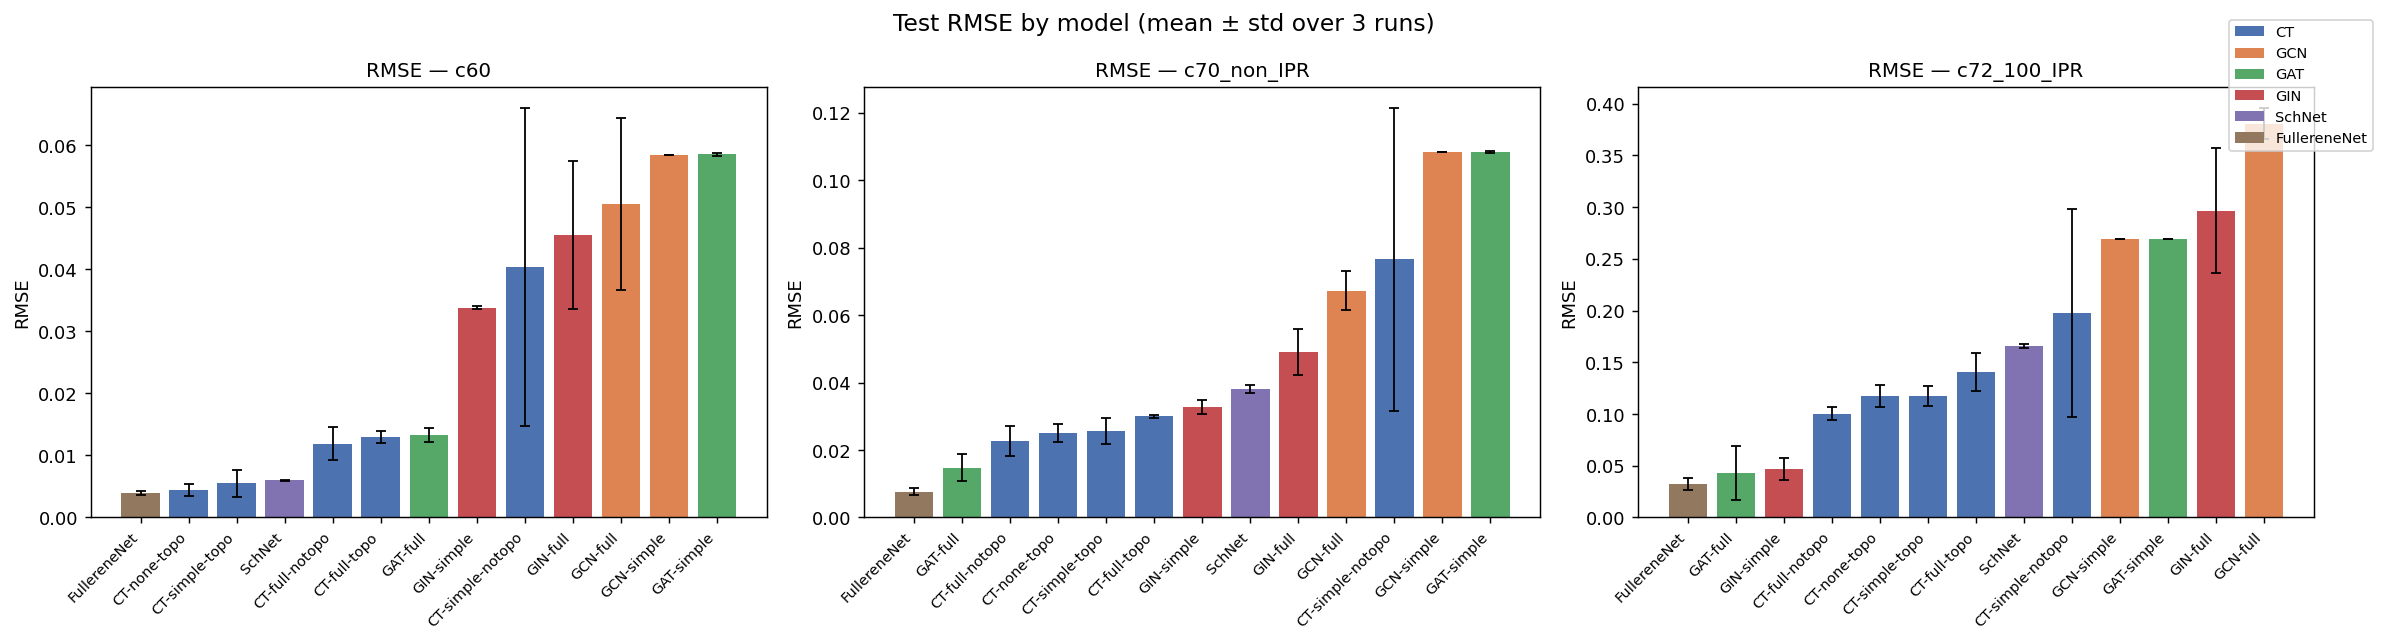

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

COLORS = {
    'CT':         '#4C72B0',
    'GCN':        '#DD8452',
    'GAT':        '#55A868',
    'GIN':        '#C44E52',
    'SchNet':     '#8172B2',
    'FullereneNet': '#937860',
}

def model_color(label):
    for prefix, c in COLORS.items():
        if label.startswith(prefix):
            return c
    return 'gray'

for ax, ts in zip(axes, TEST_SETS):
    col = f'rmse_{ts}'
    vals = df[col].dropna().sort_values()
    std_vals = df.loc[vals.index, f'rmse_{ts}_std']
    colors = [model_color(m) for m in vals.index]
    ax.bar(range(len(vals)), vals.values, color=colors, yerr=std_vals.values,
           capsize=3, error_kw={'linewidth': 1})
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(vals.index, rotation=45, ha='right', fontsize=8)
    ax.set_title(f'RMSE — {ts}', fontsize=11)
    ax.set_ylabel('RMSE')

# legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=k) for k, c in COLORS.items()]
fig.legend(handles=legend_elements, loc='upper right', fontsize=8, ncol=1,
           bbox_to_anchor=(1.02, 0.98))
plt.suptitle('Test RMSE by model (mean ± std over 3 runs)', fontsize=13)
plt.tight_layout()
plt.show()

## R² Heatmap

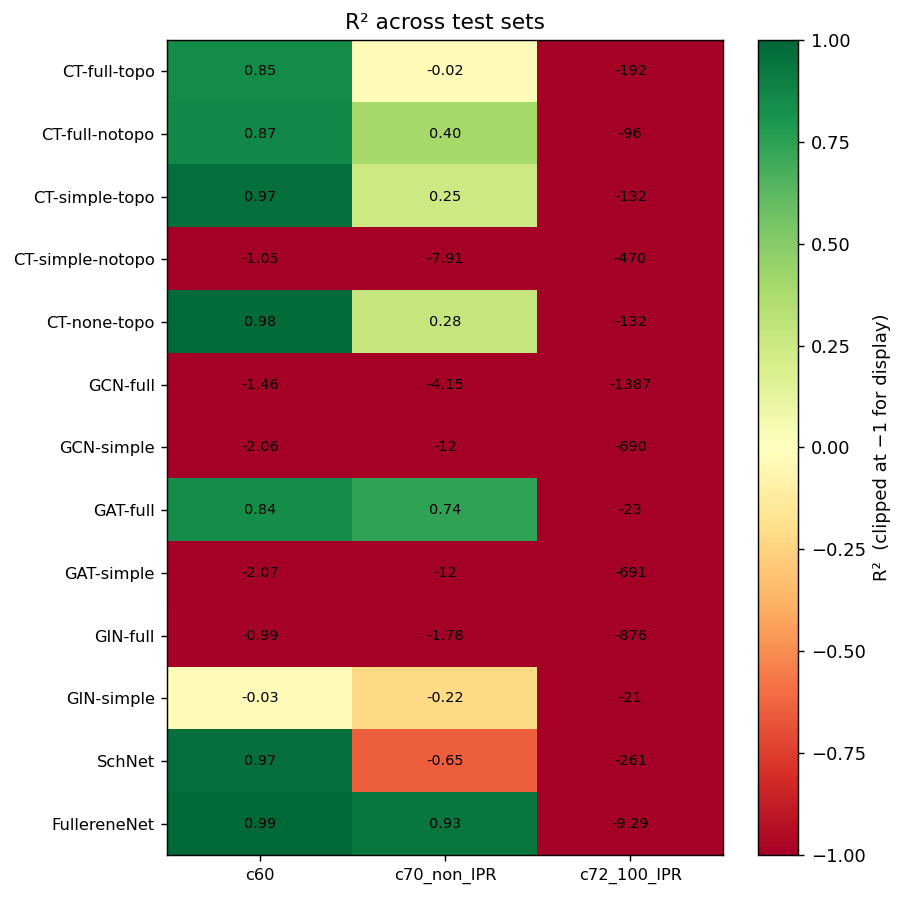

In [6]:
r2_cols = [f'r2_{ts}' for ts in TEST_SETS]
r2_df = df[r2_cols].copy()
r2_df.columns = TEST_SETS

# clip extreme negatives for display
r2_display = r2_df.clip(lower=-2)

fig, ax = plt.subplots(figsize=(7, 7))
im = ax.imshow(r2_display.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(TEST_SETS)))
ax.set_xticklabels(TEST_SETS, fontsize=9)
ax.set_yticks(range(len(r2_df)))
ax.set_yticklabels(r2_df.index, fontsize=9)
plt.colorbar(im, ax=ax, label='R²  (clipped at −1 for display)')
ax.set_title('R² across test sets', fontsize=12)
for i in range(len(r2_df)):
    for j in range(len(TEST_SETS)):
        val = r2_df.values[i, j]
        if val is not None and not np.isnan(float(val)):
            txt = f'{val:.2f}' if val >= -9.99 else f'{val:.0f}'
            ax.text(j, i, txt, ha='center', va='center', fontsize=8)
plt.tight_layout()
plt.show()

## Training Loss Curves

/var/folders/_s/xqcc3j2x28g9tdmq2rg783xh0000gn/T/ipykernel_42490/1802603020.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', len(models))


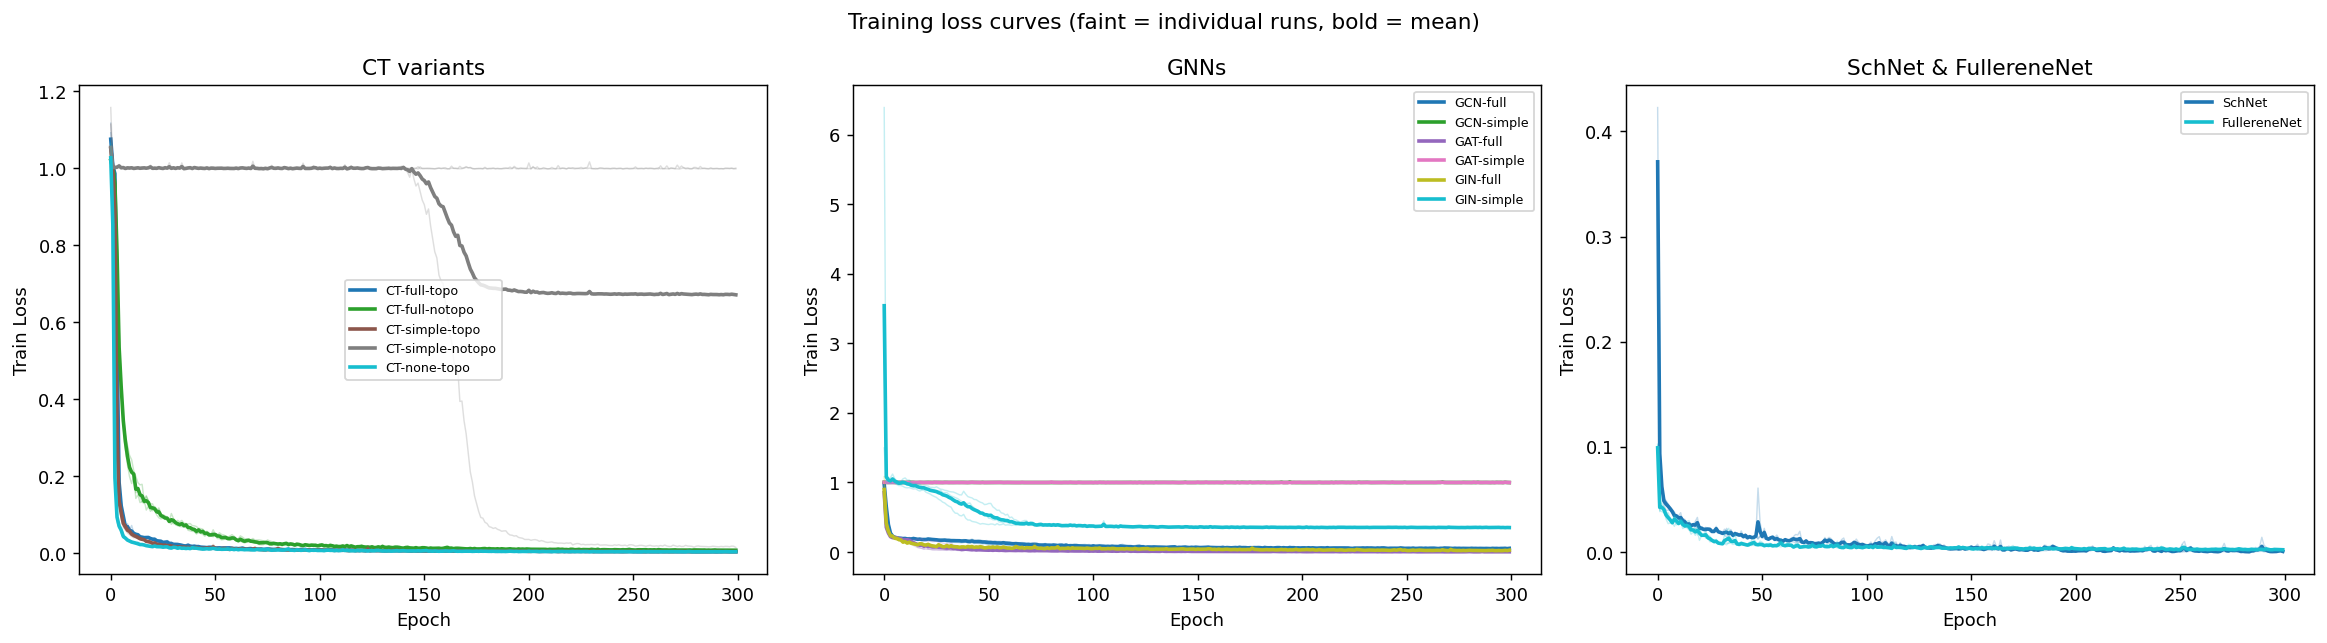

In [7]:
GROUPS = {
    'CT variants': [k for k in data if k.startswith('CT')],
    'GNNs':        [k for k in data if k.startswith(('GCN', 'GAT', 'GIN'))],
    'SchNet & FullereneNet': [k for k in data if k in ('SchNet', 'FullereneNet')],
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (group_name, models) in zip(axes, GROUPS.items()):
    cmap = cm.get_cmap('tab10', len(models))
    for idx, label in enumerate(models):
        if label not in data:
            continue
        d = data[label]
        all_losses = [r['train_losses'] for r in d['runs']]
        min_len = min(len(l) for l in all_losses)
        mean_losses = np.mean([l[:min_len] for l in all_losses], axis=0)
        color = cmap(idx)
        for l in all_losses:
            ax.plot(l[:min_len], color=color, alpha=0.25, linewidth=0.8)
        ax.plot(mean_losses, color=color, linewidth=2, label=label)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Train Loss')
    ax.set_title(group_name)
    ax.legend(fontsize=7)

plt.suptitle('Training loss curves (faint = individual runs, bold = mean)', fontsize=12)
plt.tight_layout()
plt.show()

## Per-Run Variation (Box Plots)

/var/folders/_s/xqcc3j2x28g9tdmq2rg783xh0000gn/T/ipykernel_42490/2866234327.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(sorted_values, labels=sorted_labels, vert=True)
/var/folders/_s/xqcc3j2x28g9tdmq2rg783xh0000gn/T/ipykernel_42490/2866234327.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(sorted_values, labels=sorted_labels, vert=True)
/var/folders/_s/xqcc3j2x28g9tdmq2rg783xh0000gn/T/ipykernel_42490/2866234327.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(sorted_values, labels=sorted_labels, vert=True)


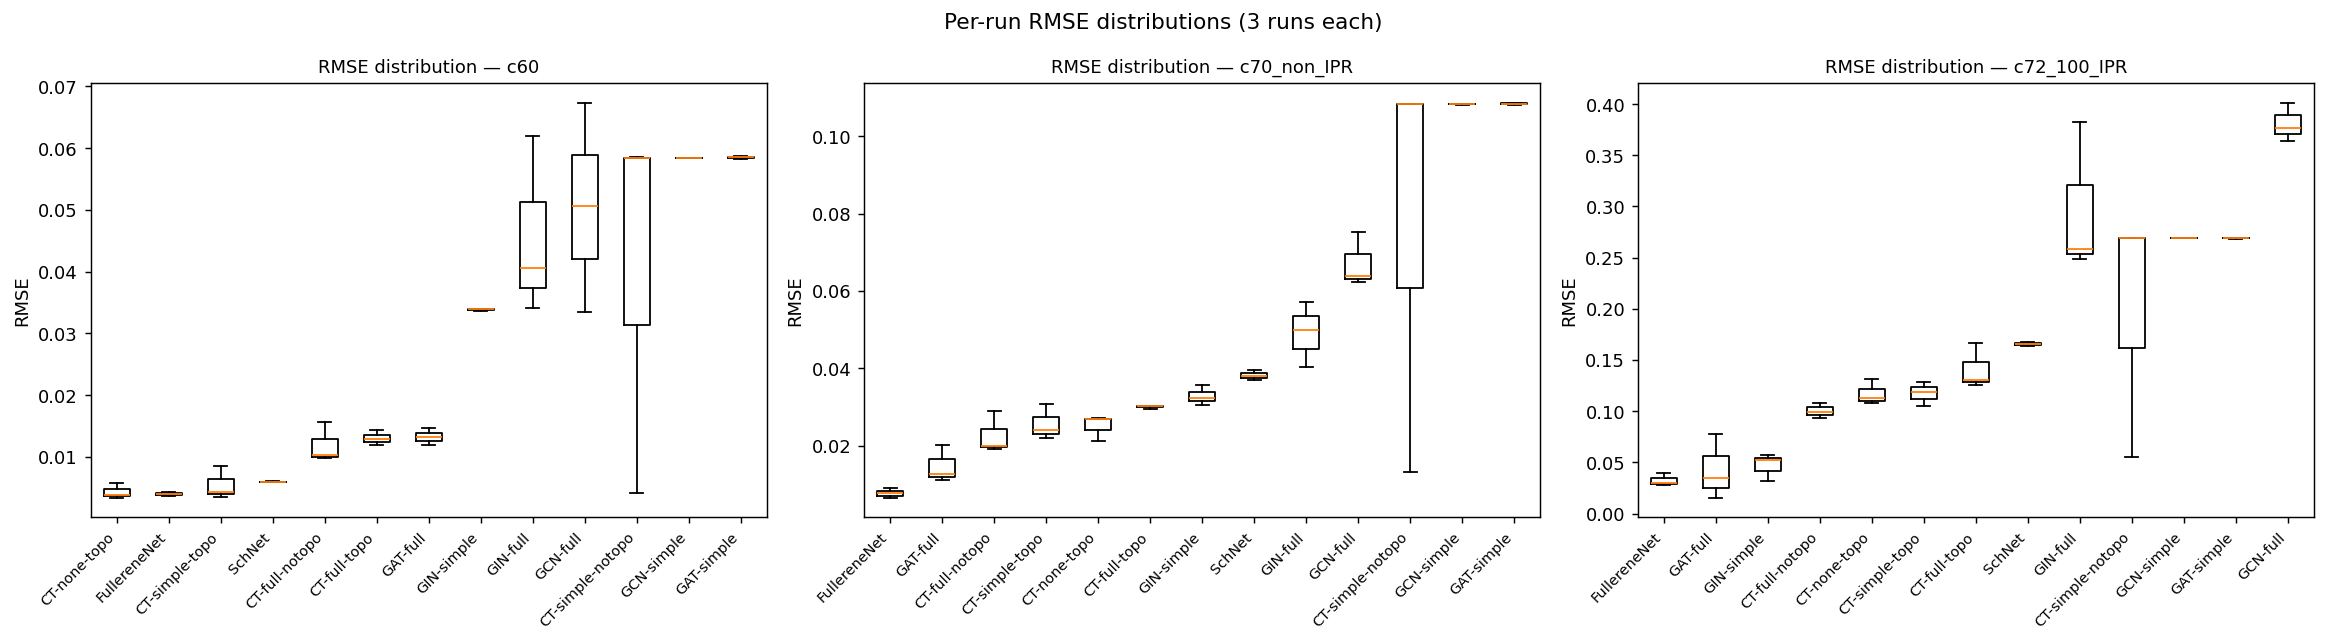

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, ts in zip(axes, TEST_SETS):
    model_labels, run_values = [], []
    for label, d in data.items():
        vals = [r[f'test_rmse_{ts}'] for r in d['runs']]
        model_labels.append(label)
        run_values.append(vals)
    # sort by median
    order = sorted(range(len(model_labels)), key=lambda i: np.median(run_values[i]))
    sorted_labels = [model_labels[i] for i in order]
    sorted_values = [run_values[i] for i in order]
    ax.boxplot(sorted_values, labels=sorted_labels, vert=True)
    ax.set_xticklabels(sorted_labels, rotation=45, ha='right', fontsize=8)
    ax.set_title(f'RMSE distribution — {ts}', fontsize=10)
    ax.set_ylabel('RMSE')

plt.suptitle('Per-run RMSE distributions (3 runs each)', fontsize=12)
plt.tight_layout()
plt.show()

## Runtime

In [9]:
runtime_rows = []
for label, d in data.items():
    runtimes = []
    for r in d['runs']:
        rt = r.get('runtime_s') or r.get('runtime')
        if rt is not None:
            runtimes.append(rt)
    if runtimes:
        runtime_rows.append({
            'model': label,
            'total_runtime_h': round(sum(runtimes) / 3600, 2),
            'per_run_h':       round(np.mean(runtimes) / 3600, 2),
            'num_params':      d.get('num_params'),
        })

rt_df = pd.DataFrame(runtime_rows).set_index('model').sort_values('per_run_h')
display(rt_df)

,total_runtime_h,per_run_h,num_params
model,,,
GIN-full,0.0900,0.0300,29956
GIN-simple,0.0900,0.0300,29444
GCN-full,0.1100,0.0400,17473
GCN-simple,0.1100,0.0400,16961
GAT-full,0.1700,0.0600,297665
GAT-simple,0.1700,0.0600,288193
FullereneNet,0.2500,0.0800,463821
CT-full-topo,9.6300,3.2100,811201
CT-simple-topo,9.6700,3.2200,808961
